# 🔧 ICU-Watch — Feature Engineering
**Author:** Subham Pal

### Goals of this notebook
1. Load processed data from EDA
2. Impute missing vital signs
3. Build lag and rate-of-change features
4. Create 12-hour rolling window sequences
5. Assign 6-hour ahead sepsis labels
6. Split into train / val / test sets
7. Save as numpy arrays ready for PyTorch LSTM

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR      = Path('../data/processed')
RAW_DIR       = Path('../data/raw/training')
RESEARCH_DIR  = Path('../research/notes')

# Core modeling config
WINDOW_SIZE   = 12   # hours of history fed to LSTM
HORIZON       = 6    # hours ahead we predict sepsis
VITAL_COLS    = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']
RANDOM_STATE  = 42

print('Setup complete')
print(f'Window size:        {WINDOW_SIZE} hours')
print(f'Prediction horizon: {HORIZON} hours ahead')
print(f'Core vital features: {VITAL_COLS}')

Setup complete
Window size:        12 hours
Prediction horizon: 6 hours ahead
Core vital features: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']


## 1. Load Data from EDA

In [2]:
print('Loading full dataset from EDA...')
df = pd.read_parquet(DATA_DIR / 'full_dataset.parquet')
patient_summary = pd.read_parquet(DATA_DIR / 'patient_summary.parquet')

print(f'Loaded: {len(df):,} rows, {df["patient_id"].nunique():,} patients')
print(f'Columns: {len(df.columns)}')
df[VITAL_COLS + ['SepsisLabel', 'patient_id', 'hour']].head()

Loading full dataset from EDA...
Loaded: 1,552,210 rows, 40,336 patients
Columns: 44


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,SepsisLabel,patient_id,hour
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,p000001,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,0,p000001,1
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,0,p000001,2
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,0,p000001,3
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,0,p000001,4


## 2. Missing Data Imputation

In [3]:
print('=== BEFORE IMPUTATION ===')
missing_before = df[VITAL_COLS].isnull().mean() * 100
print(missing_before.round(1).to_string())

def impute_vitals(df: pd.DataFrame, vital_cols: list) -> pd.DataFrame:
    """
    Per-patient imputation strategy:
    1. Forward fill (carry last known value, max 2 hours)
    2. Backward fill (for missing values at start of stay)
    3. Population median fill (for patients with no readings)
    """
    df = df.copy()
    
    # Step 1 & 2: per-patient forward then backward fill
    df[vital_cols] = (
        df.groupby('patient_id')[vital_cols]
        .transform(lambda x: x.ffill(limit=2).bfill(limit=2))
    )
    
    # Step 3: population median for remaining NaNs
    pop_medians = df[vital_cols].median()
    df[vital_cols] = df[vital_cols].fillna(pop_medians)
    
    return df

df = impute_vitals(df, VITAL_COLS)

print('\n=== AFTER IMPUTATION ===')
missing_after = df[VITAL_COLS].isnull().mean() * 100
print(missing_after.round(1).to_string())
print(f'\nTotal remaining NaNs: {df[VITAL_COLS].isnull().sum().sum()}')

=== BEFORE IMPUTATION ===
HR        9.9
O2Sat    13.1
Temp     66.2
SBP      14.6
MAP      12.5
DBP      31.3
Resp     15.4

=== AFTER IMPUTATION ===
HR       0.0
O2Sat    0.0
Temp     0.0
SBP      0.0
MAP      0.0
DBP      0.0
Resp     0.0

Total remaining NaNs: 0


## 3. Feature Engineering

In [4]:
def add_lag_features(df: pd.DataFrame, vital_cols: list, lags=[1, 2, 4, 6]) -> pd.DataFrame:
    """
    Lag features: vital sign values from N hours ago.
    Gives LSTM explicit access to historical values.
    """
    df = df.copy()
    for vital in vital_cols:
        for lag in lags:
            df[f'{vital}_lag{lag}h'] = (
                df.groupby('patient_id')[vital]
                .transform(lambda x: x.shift(lag))
            )
    return df


def add_rate_of_change(df: pd.DataFrame, vital_cols: list, windows=[1, 4]) -> pd.DataFrame:
    """
    Rate of change features: is this vital rising or falling?
    Critical for detecting deterioration trends.
    """
    df = df.copy()
    for vital in vital_cols:
        for w in windows:
            df[f'{vital}_roc{w}h'] = (
                df.groupby('patient_id')[vital]
                .transform(lambda x: x.diff(w))
            )
    return df


def add_rolling_stats(df: pd.DataFrame, vital_cols: list, windows=[4, 12]) -> pd.DataFrame:
    """
    Rolling statistics: mean and std over past N hours.
    Std captures instability — a key early deterioration signal.
    """
    df = df.copy()
    for vital in vital_cols:
        for w in windows:
            df[f'{vital}_mean{w}h'] = (
                df.groupby('patient_id')[vital]
                .transform(lambda x: x.rolling(w, min_periods=1).mean())
            )
            df[f'{vital}_std{w}h'] = (
                df.groupby('patient_id')[vital]
                .transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
            )
    return df


print('Adding lag features...')
df = add_lag_features(df, VITAL_COLS, lags=[1, 2, 4, 6])

print('Adding rate of change features...')
df = add_rate_of_change(df, VITAL_COLS, windows=[1, 4])

print('Adding rolling statistics...')
df = add_rolling_stats(df, VITAL_COLS, windows=[4, 12])

# Fill any NaNs introduced by lag/diff operations
df = df.fillna(0)

# Get all feature columns
FEATURE_COLS = [c for c in df.columns 
                if c not in ['patient_id', 'SepsisLabel', 'hour', 'dataset',
                             'ICULOS', 'HospAdmTime', 'Unit1', 'Unit2', 'Gender', 'Age']]

print(f'\nTotal features created: {len(FEATURE_COLS)}')
print(f'Feature breakdown:')
print(f'  Core vitals:          {len(VITAL_COLS)}')
print(f'  Lag features:         {len(VITAL_COLS) * 4}')
print(f'  Rate of change:       {len(VITAL_COLS) * 2}')
print(f'  Rolling mean/std:     {len(VITAL_COLS) * 4}')

Adding lag features...
Adding rate of change features...
Adding rolling statistics...

Total features created: 104
Feature breakdown:
  Core vitals:          7
  Lag features:         28
  Rate of change:       14
  Rolling mean/std:     28


## 4. Create 6-Hour Ahead Labels

In [5]:
def create_prediction_labels(df: pd.DataFrame, horizon: int = 6) -> pd.DataFrame:
    """
    Label = 1 if sepsis occurs within the next HORIZON hours.
    This is what our model learns to predict.
    """
    df = df.copy()
    
    def label_patient(group):
        sepsis_hours = set(group[group['SepsisLabel'] == 1]['hour'].values)
        labels = []
        for _, row in group.iterrows():
            # Check if any of the next HORIZON hours have sepsis
            future_hours = set(range(int(row['hour']) + 1, int(row['hour']) + horizon + 1))
            labels.append(1 if future_hours & sepsis_hours else 0)
        group['label_6h'] = labels
        return group
    
    tqdm.pandas(desc='Creating 6h labels')
    df = df.groupby('patient_id', group_keys=False).progress_apply(label_patient)
    
    return df

print('Creating 6-hour ahead prediction labels...')
df = create_prediction_labels(df, horizon=HORIZON)

label_counts = df['label_6h'].value_counts()
print(f'\nLabel distribution:')
print(f'  No deterioration (0): {label_counts[0]:,} ({label_counts[0]/len(df)*100:.1f}%)')
print(f'  Deterioration (1):    {label_counts[1]:,} ({label_counts[1]/len(df)*100:.1f}%)')
print(f'\nNote: More positive labels than raw sepsis rate')
print(f'because each patient contributes multiple labeled time windows')

Creating 6-hour ahead prediction labels...


Creating 6h labels: 100%|█████████████████████████████████████| 40336/40336 [01:09<00:00, 579.15it/s]



Label distribution:
  No deterioration (0): 1,513,147 (97.5%)
  Deterioration (1):    39,063 (2.5%)

Note: More positive labels than raw sepsis rate
because each patient contributes multiple labeled time windows


## 5. Build Sliding Window Sequences

In [6]:
def build_sequences(df: pd.DataFrame, 
                    feature_cols: list,
                    window_size: int = 12) -> tuple:
    """
    Convert time series into (X, y) sequences for LSTM.
    
    For each valid time step t:
    X[t] = features from hours [t-window_size+1 ... t]  shape: (window_size, n_features)
    y[t] = label_6h at hour t                           shape: (1,)
    
    Only includes windows with full WINDOW_SIZE hours of history.
    """
    X_list, y_list, pid_list = [], [], []
    
    for pid, group in tqdm(df.groupby('patient_id'), desc='Building sequences'):
        group = group.sort_values('hour').reset_index(drop=True)
        features = group[feature_cols].values
        labels   = group['label_6h'].values
        
        # Slide window across patient timeline
        for i in range(window_size - 1, len(group)):
            window = features[i - window_size + 1 : i + 1]  # shape: (window_size, n_features)
            label  = labels[i]
            
            X_list.append(window)
            y_list.append(label)
            pid_list.append(pid)
    
    X = np.array(X_list, dtype=np.float32)   # (n_samples, window_size, n_features)
    y = np.array(y_list, dtype=np.float32)   # (n_samples,)
    pids = np.array(pid_list)                # (n_samples,)
    
    return X, y, pids

print(f'Building {WINDOW_SIZE}-hour sliding window sequences...')
X, y, pids = build_sequences(df, FEATURE_COLS, window_size=WINDOW_SIZE)

print(f'\nSequences built!')
print(f'X shape: {X.shape}  — (samples, time_steps, features)')
print(f'y shape: {y.shape}  — (samples,)')
print(f'Positive rate: {y.mean()*100:.2f}%')

Building 12-hour sliding window sequences...


Building sequences: 100%|████████████████████████████████████| 40336/40336 [00:25<00:00, 1581.71it/s]



Sequences built!
X shape: (1110191, 12, 104)  — (samples, time_steps, features)
y shape: (1110191,)  — (samples,)
Positive rate: 2.68%


## 6. Normalize Features

In [7]:
# Normalize using StandardScaler — fit only on train data to prevent leakage
# First: patient-level split to prevent data leakage

unique_pids = np.unique(pids)
train_pids, temp_pids = train_test_split(unique_pids, test_size=0.30, 
                                          random_state=RANDOM_STATE)
val_pids, test_pids   = train_test_split(temp_pids,   test_size=0.50, 
                                          random_state=RANDOM_STATE)

# Create masks
train_mask = np.isin(pids, train_pids)
val_mask   = np.isin(pids, val_pids)
test_mask  = np.isin(pids, test_pids)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# Normalize: fit scaler on training data only
n_samples, n_steps, n_features = X_train.shape
scaler = StandardScaler()

# Reshape to 2D for scaler, then back to 3D
X_train_2d = X_train.reshape(-1, n_features)
scaler.fit(X_train_2d)

X_train = scaler.transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
X_val   = scaler.transform(X_val.reshape(-1, n_features)).reshape(X_val.shape)
X_test  = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

print('=== TRAIN / VAL / TEST SPLITS ===')
print(f'Train:  {X_train.shape[0]:>8,} sequences | {train_mask.sum()/len(X)*100:.1f}% | Sepsis rate: {y_train.mean()*100:.2f}%')
print(f'Val:    {X_val.shape[0]:>8,} sequences | {val_mask.sum()/len(X)*100:.1f}% | Sepsis rate: {y_val.mean()*100:.2f}%')
print(f'Test:   {X_test.shape[0]:>8,} sequences | {test_mask.sum()/len(X)*100:.1f}% | Sepsis rate: {y_test.mean()*100:.2f}%')
print(f'\nFeature shape per sequence: ({WINDOW_SIZE} timesteps x {n_features} features)')
print(f'\nNote: Split is PATIENT-LEVEL — no patient appears in both train and test')
print(f'This is critical to prevent data leakage in time-series medical data')

=== TRAIN / VAL / TEST SPLITS ===
Train:   777,795 sequences | 70.1% | Sepsis rate: 2.66%
Val:     165,479 sequences | 14.9% | Sepsis rate: 2.64%
Test:    166,917 sequences | 15.0% | Sepsis rate: 2.81%

Feature shape per sequence: (12 timesteps x 104 features)

Note: Split is PATIENT-LEVEL — no patient appears in both train and test
This is critical to prevent data leakage in time-series medical data


## 7. Visualize Feature Distributions After Engineering

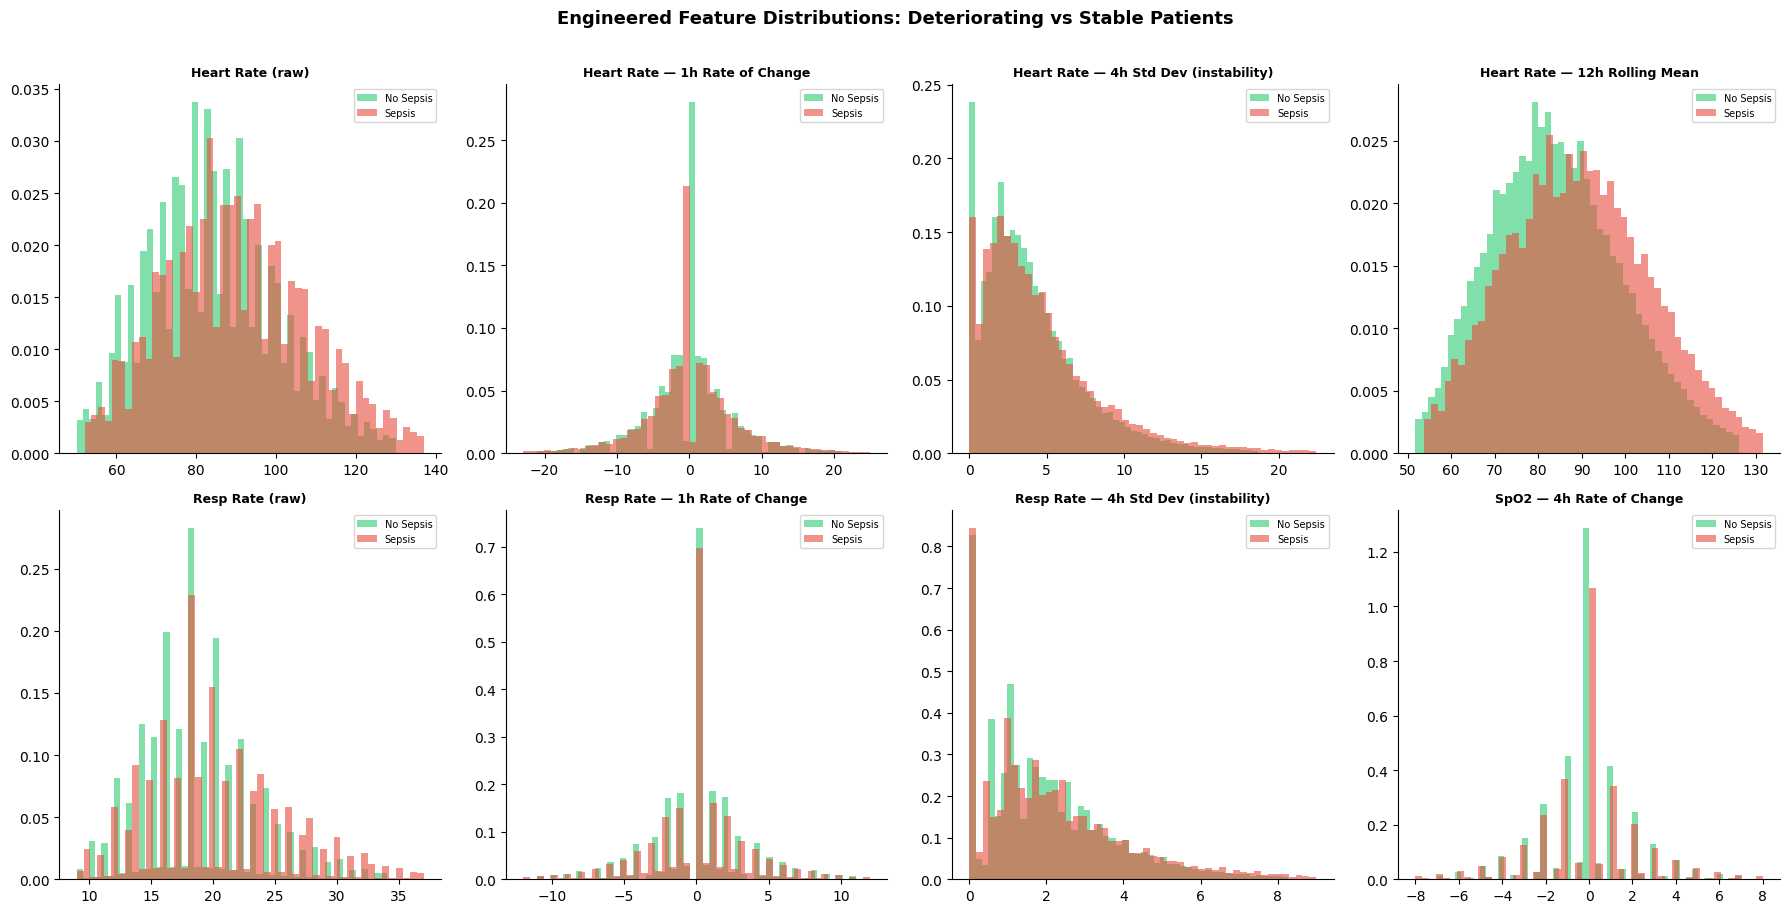

Saved to research/notes/feature_distributions.png


In [8]:
# Visualize key engineered features
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

engineered_features = [
    ('HR',          'Heart Rate (raw)'),
    ('HR_roc1h',    'Heart Rate — 1h Rate of Change'),
    ('HR_std4h',    'Heart Rate — 4h Std Dev (instability)'),
    ('HR_mean12h',  'Heart Rate — 12h Rolling Mean'),
    ('Resp',        'Resp Rate (raw)'),
    ('Resp_roc1h',  'Resp Rate — 1h Rate of Change'),
    ('Resp_std4h',  'Resp Rate — 4h Std Dev (instability)'),
    ('O2Sat_roc4h', 'SpO2 — 4h Rate of Change'),
]

for i, (feat, label) in enumerate(engineered_features):
    ax = axes[i]
    if feat not in df.columns:
        continue
    for sep_val, color, name in [(0,'#2ecc71','No Sepsis'),(1,'#e74c3c','Sepsis')]:
        data = df[df['label_6h']==sep_val][feat].dropna()
        data = data[data.between(data.quantile(0.01), data.quantile(0.99))]  # remove outliers for viz
        ax.hist(data, bins=50, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('Engineered Feature Distributions: Deteriorating vs Stable Patients',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESEARCH_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to research/notes/feature_distributions.png')

## 8. Class Imbalance Strategy

=== CLASS IMBALANCE STRATEGY ===
Training negatives (no deterioration): 757,106
Training positives (deterioration):    20,689
Positive weight for loss function:     36.59x

This means missing a sepsis case is penalized 36.6x
more than a false alarm — clinically correct.

In PyTorch:
  pos_weight = torch.tensor([36.59])
  criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


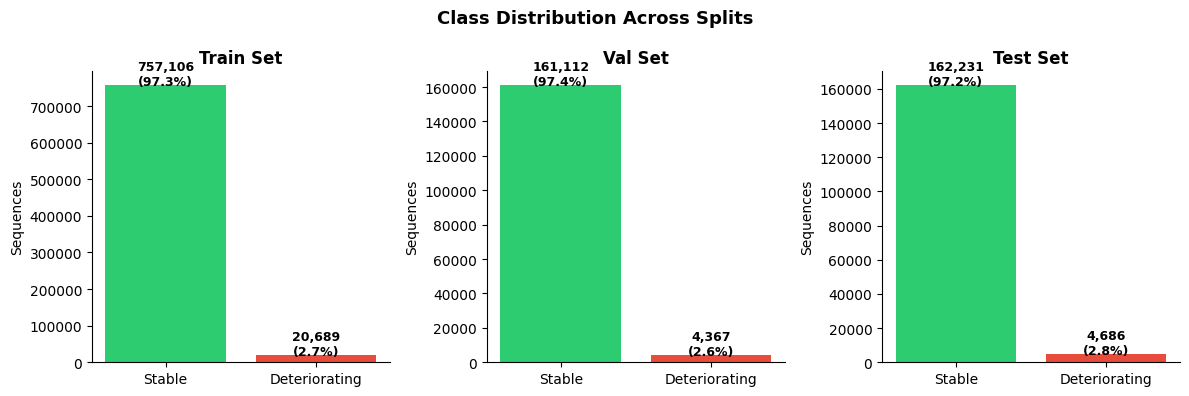

In [9]:
# Calculate class weights for loss function
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()
pos_weight  = n_negative / n_positive

print('=== CLASS IMBALANCE STRATEGY ===')
print(f'Training negatives (no deterioration): {n_negative:,}')
print(f'Training positives (deterioration):    {n_positive:,}')
print(f'Positive weight for loss function:     {pos_weight:.2f}x')
print(f'\nThis means missing a sepsis case is penalized {pos_weight:.1f}x')
print(f'more than a false alarm — clinically correct.')
print(f'\nIn PyTorch:')
print(f'  pos_weight = torch.tensor([{pos_weight:.2f}])')
print(f'  criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)')

# Visualize class balance in each split
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, y_split) in zip(axes, [('Train', y_train), ('Val', y_val), ('Test', y_test)]):
    counts = [( y_split == 0).sum(), (y_split == 1).sum()]
    ax.bar(['Stable', 'Deteriorating'], counts, color=['#2ecc71', '#e74c3c'])
    ax.set_title(f'{name} Set', fontweight='bold')
    ax.set_ylabel('Sequences')
    for j, v in enumerate(counts):
        ax.text(j, v + 100, f'{v:,}\n({v/sum(counts)*100:.1f}%)', 
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Class Distribution Across Splits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESEARCH_DIR / 'class_balance_splits.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Everything for Model Training

In [10]:
# Save numpy arrays
print('Saving processed sequences...')
np.save(DATA_DIR / 'X_train.npy', X_train)
np.save(DATA_DIR / 'y_train.npy', y_train)
np.save(DATA_DIR / 'X_val.npy',   X_val)
np.save(DATA_DIR / 'y_val.npy',   y_val)
np.save(DATA_DIR / 'X_test.npy',  X_test)
np.save(DATA_DIR / 'y_test.npy',  y_test)

# Save scaler and feature list for inference
joblib.dump(scaler,       DATA_DIR / 'scaler.pkl')
joblib.dump(FEATURE_COLS, DATA_DIR / 'feature_cols.pkl')

# Save config
import json
config = {
    'window_size':   WINDOW_SIZE,
    'horizon':       HORIZON,
    'n_features':    n_features,
    'pos_weight':    float(pos_weight),
    'vital_cols':    VITAL_COLS,
    'feature_cols':  FEATURE_COLS,
    'train_samples': int(X_train.shape[0]),
    'val_samples':   int(X_val.shape[0]),
    'test_samples':  int(X_test.shape[0]),
    'sepsis_rate_train': float(y_train.mean()),
}

with open(DATA_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('\n=== SAVED FILES ===')
for f in sorted(DATA_DIR.glob('*')):
    size = f.stat().st_size / (1024*1024)
    print(f'  {f.name:<30} {size:.1f} MB')

print(f'\n✅ Feature engineering complete!')
print(f'Next: notebooks/03_baseline_model.ipynb')

Saving processed sequences...

=== SAVED FILES ===
  .gitkeep                       0.0 MB
  config.json                    0.0 MB
  feature_cols.pkl               0.0 MB
  full_dataset.parquet           16.5 MB
  patient_summary.parquet        0.6 MB
  scaler.pkl                     0.0 MB
  X_test.npy                     794.6 MB
  X_train.npy                    3702.9 MB
  X_val.npy                      787.8 MB
  y_test.npy                     0.6 MB
  y_train.npy                    3.0 MB
  y_val.npy                      0.6 MB

✅ Feature engineering complete!
Next: notebooks/03_baseline_model.ipynb


## 10. Feature Engineering Summary

In [11]:
print('=' * 58)
print('   ICU-WATCH FEATURE ENGINEERING — SUMMARY')
print('=' * 58)
print(f'''
📐 SEQUENCE DESIGN
   Window size:          {WINDOW_SIZE} hours of history
   Prediction horizon:   {HORIZON} hours ahead
   Input shape:          ({WINDOW_SIZE}, {n_features}) per sequence

🔧 FEATURES BUILT ({n_features} total)
   Core vitals:          {len(VITAL_COLS)} (HR, SpO2, Temp, SBP, MAP, DBP, Resp)
   Lag features:         {len(VITAL_COLS)*4} (1h, 2h, 4h, 6h ago)
   Rate of change:       {len(VITAL_COLS)*2} (1h and 4h delta)
   Rolling mean:         {len(VITAL_COLS)*2} (4h and 12h window)
   Rolling std:          {len(VITAL_COLS)*2} (4h and 12h window)

🧹 IMPUTATION STRATEGY
   Forward fill:         Max 2 hours per gap
   Backward fill:        For missing values at stay start
   Population median:    For remaining NaNs

📊 DATASET SPLITS (patient-level, no leakage)
   Train:  {X_train.shape[0]:,} sequences ({y_train.mean()*100:.2f}% positive)
   Val:    {X_val.shape[0]:,} sequences ({y_val.mean()*100:.2f}% positive)
   Test:   {X_test.shape[0]:,} sequences ({y_test.mean()*100:.2f}% positive)

⚖️ CLASS IMBALANCE
   Positive weight:      {pos_weight:.2f}x
   Strategy:             BCEWithLogitsLoss(pos_weight={pos_weight:.2f})
''')
print('=' * 58)

   ICU-WATCH FEATURE ENGINEERING — SUMMARY

📐 SEQUENCE DESIGN
   Window size:          12 hours of history
   Prediction horizon:   6 hours ahead
   Input shape:          (12, 104) per sequence

🔧 FEATURES BUILT (104 total)
   Core vitals:          7 (HR, SpO2, Temp, SBP, MAP, DBP, Resp)
   Lag features:         28 (1h, 2h, 4h, 6h ago)
   Rate of change:       14 (1h and 4h delta)
   Rolling mean:         14 (4h and 12h window)
   Rolling std:          14 (4h and 12h window)

🧹 IMPUTATION STRATEGY
   Forward fill:         Max 2 hours per gap
   Backward fill:        For missing values at stay start
   Population median:    For remaining NaNs

📊 DATASET SPLITS (patient-level, no leakage)
   Train:  777,795 sequences (2.66% positive)
   Val:    165,479 sequences (2.64% positive)
   Test:   166,917 sequences (2.81% positive)

⚖️ CLASS IMBALANCE
   Positive weight:      36.59x
   Strategy:             BCEWithLogitsLoss(pos_weight=36.59)

